<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN (K-nearest Neighbors)
Bài này sẽ chủ yếu nói về KNN hay K-lân cận - một thuật toán máy học ở dạng học có giám sát

Trong bài này thì sẽ đi qua lý thuyết -> code.

In [ ]:
import numpy as np
from numpy import linalg
from IPython.display import Image, display
from google.colab import drive
from time import time
import matplotlib.pyplot as plt

## Definition
KNN hay K-lân cận được xem là thuật toán học có giám sát đơn giản nhất, và cũng là thuật toán đa dụng khi có thể ứng dụng trong có 2 task là phân loại và hồi quy.[1]

Khi huấn luyện, KNN hầu như không học được điều gì từ dữ liệu mà nó sẽ ghi nhớ toàn bộ điểm dữ liệu đó nên người ta còn ví von KNN là loại thuật toán lười học, nói một cách "chuẩn" theo kiểu Machine Learning hơn thì là instance-based learning, hay memory-based learning. Mọi tính toán được thực hiện tại thời điểm kiểm tra (test phase)[1]

KNN là thuật toán đi tìm đầu ra của một điểm dữ liệu dựa trên K điểm dữ liệu gần nhất trong tập huấn luyện.

Với KNN, mọi điểm trong tập dữ liệu đều được mô tả một cách chính xác $\Rightarrow$ Dễ overfitting

## Khoảng cách từ một điểm tới từng điểm trong một tập hợp
Khoảng cách từ một điểm $\mathbf{z}$ đến một điểm $\mathbf{x_i}$ trong tập huấn luyện (xét ở không gian Euclidean) được định nghĩa thông qua $\left\|\mathbf{z}-\mathbf{x_i}\right\|_2$ hoặc thông qua bình phương khoảng cách $\left\|\mathbf{z}-\mathbf{x_i}\right\|_2^2$

Phân tích sâu hơn tí, ta có:
$$
\left\|\mathbf{z} - \mathbf{x_i}\right\|_2^2 = (\mathbf{z}-\mathbf{x_i})^T(\mathbf{z}-\mathbf{x_i}) = \left\|\mathbf{z}\right\|_2^2 + \left\|\mathbf{x_i}\right\|_2^2 - 2\mathbf{x_i}^T\cdot \mathbf{z} \tag{1}
$$

Nếu có nhiều điểm trong tập kiểm tra, ta có thể lưu trữ trước các giá trị $\left\|\mathbf{x_i}\right\|_2^2$ trong bộ nhớ. Khi đó ta chỉ cần tính toán tích vô hướng cuối cùng là $\mathbf{x_i}^T \cdot \mathbf{z}$

Giả sử các điểm dữ liệu huấn luyện là các vector $d$ chiều $\mathbf{x_i} \in \mathcal{R}^d$ và có $N$ điểm dữ liệu nói trên xếp thành các cột trong ma trận đầu vào $\mathbf{X} \in \mathcal{R}^{d\times N}$

KNN sẽ phải tính khoảng cách từ một điểm dữ liệu mới $\mathbf{z} \in \mathcal{R}^d$ đến toàn bộ $N$ điểm dữ liệu đã cho và chọn ra $K$ khoảng cách nhỏ nhất. Nếu không có cách tính hiệu quả, khối lượng tính toán sẽ rất lớn. Do đó thì ta xét thử một vài cách tính sau đây và chọn ra cách tiêu tốn ít thời gian tính toán nhất.

In [ ]:
# Choose dimension and number of training points
d, N = 1000, 10000

# Initialize X and z randomly
X = np.random.rand(N, d)
z = np.random.rand(d)

In [ ]:
# Compute distance between z and x using l2-norm
def dist_pp(z, x):
  d = z - x.reshape(z.shape)
  return np.sum(d*d)

In [ ]:
# from one point to each point in a set, naive
def dist_ps_naive(z, X):
  N = X.shape[0]
  res = np.zeros((1, N))
  for i in range(N):
    res[0][i] = dist_pp(z, X[i])
  return res

In [ ]:
# from one point to each point in a set, fast
def dist_ps_fast(z, X):
  X2 = np.sum(X*X, 1)
  z2 = np.sum(z*z)
  return X2 + z2 - 2*X.dot(z)

In [ ]:
start_dist_naive = time()
dist_naive = dist_ps_naive(z, X)
end_dist_naive = time()
time_to_compute_naive_dist = end_dist_naive - start_dist_naive
print(f'naive point2set, running time: {time_to_compute_naive_dist}s')

naive point2set, running time: 0.09032535552978516s


In [ ]:
start_disc_fast = time()
dist_fast = dist_ps_fast(z, X)
end_dist_fast = time()
time_to_compute_fast_dist = end_dist_fast - start_disc_fast
print(f'fast point2set, running time: {time_to_compute_fast_dist}s')

fast point2set, running time: 0.04644632339477539s


In [ ]:
# Difference
print(f'Result difference between two methods: {np.linalg.norm(dist_fast - dist_naive)}')

Result difference between two methods: 1.2403658620482163e-11


Kết quả chỉ ra rằng hàm `dist_ps_fast(z, X)` chạy nhanh hơn gần gấp đôi so với
hàm `dist_ps_naive(z, X)`. Tỉ lệ này còn lớn hơn khi kích thước dữ liệu tăng lên và `X2` được tính từ trước. Quan trọng hơn, sự chênh lệch nhỏ giữa kết quả của hai cách tính chỉ ra rằng `dist_ps_fast(z, X)` nên được ưu tiên hơn.

## Khoảng cách giữa từng cặp điểm trong 2 tập hợp
Tập kiểm tra bao gồm nhiều điểm dữ liệu, các điểm dữ liệu này là các vector và được xếp theo từng hàng, tạo thành ma trận $Z$, ta phải tính từng cặp điểm lấy từ tập test và tập training. Nếu mỗi tập có 1000 phần tử, có một triệu khoảng
cách cần tính. Nếu không có phương pháp tính hiệu quả, thời gian thực hiện sẽ
rất dài.



Ta tiếp tục tính toán và so sánh 2 cách sau:
- Cách 1: Sử dụng vòng lặp `for` thông thường và hàm `dist_ps_fast` để tính toán.
- Cách 2: Sử dụng ý tưởng từ công thức (1).

In [ ]:
# Using for loop
def dist_ss_0(Z, X):
  M, N = Z.shape[0], X.shape[0]
  res = np.zeros((M, N))
  for i in range(M):
    res[i] = dist_ps_fast(Z[i], X)
  return res

In [ ]:
# Use (1)
def dist_ss_fast(Z, X):
  X2 = np.sum(X*X, 1)
  Z2 = np.sum(Z*Z, 1)
  return Z2.reshape(-1, 1) + X2.reshape(1, -1) - 2*Z.dot(X.T)

In [ ]:
Z = np.random.rand(100, d)
start_dist_ss_0 = time()
D1 = dist_ss_0(Z, X)
end_dist_ss_0 = time()
print(f'running time: {end_dist_ss_0 - start_dist_ss_0}s')

running time: 5.635773181915283s


In [ ]:
start_dist_ss_fast = time()
D2 = dist_ss_fast(Z, X)
end_dist_ss_fast = time()
print(f'running time: {end_dist_ss_fast - start_dist_ss_fast}s')
print(f'Result difference:, {np.linalg.norm(D1-D2)}')

running time: 0.1475365161895752s
Result difference:, 1.2343257509960002e-10


Từ đây có thể nói rằng hai cách tính cho kết quả chênh lệch nhau không đáng kể.
Trong khi đó `dist_ss_fast(Z, X)` chạy nhanh hơn `dist_ss_0(Z, X)` nhiều lần.

## Các bước tiến hành trong KNN
Các bước trong KNN:  
1. Ta có D là tập các điểm dữ liệu đã được gắn nhãn và A là dữ liệu chưa được phân loại.  
2. Đo khoảng cách (Euclidian, Manhattan, Minkowski, Minkowski hoặc Trọng số) từ dữ liệu mới A đến tất cả các dữ liệu khác đã được phân loại trong D.  
3. Chọn K (K là tham số do chính mình định nghĩa) khoảng cách nhỏ nhất.
Kiểm tra danh sách các lớp có khoảng cách ngắn nhất và đếm số lượng của mỗi lớp xuất hiện.  
4. Lấy đúng lớp (lớp xuất hiện nhiều lần nhất).
Lớp của dữ liệu mới là lớp mà ta đã nhận được ở bước 5.

# Python implementation for KNN
Dataset = Iris và MNIST

In [ ]:
from sklearn import neighbors, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [169]:
iris_datasets = datasets.load_iris()
iris_X = iris_datasets.data
iris_y = iris_datasets.target

In [170]:
print('Label', np.unique(iris_y))

np.random.seed(7)
X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=130)
print(f'Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Label [0 1 2]
Training size: 20, Test size: 130


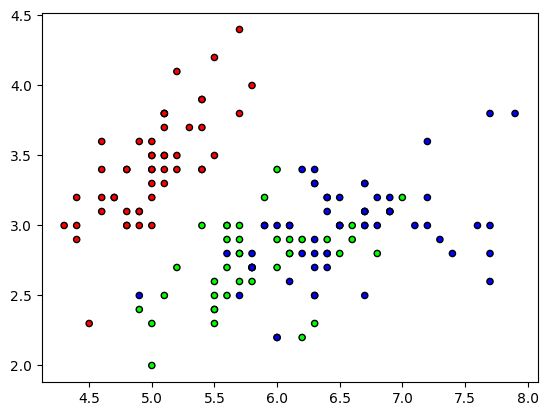

In [171]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
plt.figure()
plt.scatter(iris_X[:, 0], iris_X[:, 1], c=iris_y, cmap=cmap, edgecolors='k', s=20)
plt.show()

In [172]:
# KNN Performance when K=1 using l2-norm
model = neighbors.KNeighborsClassifier(n_neighbors=1, p=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'Accuracy of 1NN: {accuracy_score(y_test, y_pred) * 100:.4f}%')

Accuracy of 1NN: 92.3077%


In [173]:
model_1NN_l1 = neighbors.KNeighborsClassifier(n_neighbors=1, p=1)
model_1NN_l1.fit(X_train, y_train)
y_pred_1NN_l1 = model_1NN_l1.predict(X_test)
print(f'Accuracy of 1NN using L1-norm distance: {accuracy_score(y_test, y_pred_1NN_l1) * 100:.4f}%')

Accuracy of 1NN using L1-norm distance: 92.3077%


Thử lại với K=7

In [ ]:
# 4NN using L2-norm
model_7NN_l2 = neighbors.KNeighborsClassifier(n_neighbors=7, p=2)
model_7NN_l2.fit(X_train, y_train)
y_pred_7NN_l2 = model_7NN_l2.predict(X_test)
print(f'Accuracy of 10NN using L2-norm distance: {accuracy_score(y_test, y_pred_7NN_l2) * 100:.4f}%')

Accuracy of 10NN using L2-norm distance: 93.8462%


Từ kết quả thực nghiệm trên thì có thể khẳng định là khi sử dụng nhiều điểm lân cận hơn (ví dụ $K = 7$) thì độ chính xác tăng lên từ $92.3077\%$ (đối với cả `p=1` và `p=2`) lên $93.8462\%$.

Phương pháp dựa trên đa số trong lân cận còn được gọi là bầu chọn đa số.

## Đánh trọng số cho các điểm lân cận


Trong kỹ thuật bầu chọn đa số ở trên, các điểm lân cận đều có cùng một mức độ quan trọng (mức độ đóng góp hay còn gọi là trọng số) vào kết quả dự đoán cuối cùng của model là như nhau. Tức là không có điểm nào là quan trọng nhất, độ quan trọng của chúng là đồng đều.

Tuy nhiên, trong thực tế thì các điểm dữ liệu càng gần thì nên có tầm ảnh hưởng lớn hơn nên ta đánh thêm trọng số lên các điểm gần hơn ấy.

Cách đánh trọng số phải thoả mãn điều kiện điểm
lân cận hơn được đánh trọng số cao hơn. Một cách đơn giản là lấy nghịch đảo của khoảng cách tới điểm lân cận. Trong trường hợp tồn tại khoảng cách bằng không, tức điểm kiểm tra trùng với một điểm huấn luyện, ta trực tiếp lấy đầu ra
của điểm huấn luyện đó.

In [ ]:
# 7NN using L2-norm and weight = 'distance'
model_7NN_l2_w = neighbors.KNeighborsClassifier(n_neighbors=7, p=2, weights='distance')
model_7NN_l2_w.fit(X_train, y_train)
y_pred_7NN_l2_w = model_7NN_l2_w.predict(X_test)
print(f'Accuracy of 4NN using L2-norm distance and weight = "distance" (1/distance weigth): {accuracy_score(y_test, y_pred_7NN_l2_w) * 100:.4f}%')

Accuracy of 4NN using L2-norm distance and weight = "distance" (1/distance weigth): 94.6154%


Độ chính xác tiếp tục tăng lên

## KNN với trọng số tự định nghĩa
Ngoài 2 cách đánh trọng số là `uniform` và `distance` trong thư viện scikit-learn thì ta còn có thể đánh trọng số thông qua các hàm tự định nghĩa và đưa vào hàm tính toán của thư viện scikit-learn như sau

Giả sử ta đánh trọng số theo phương pháp sau:
$$
w_i = \exp(-\frac{\left\|\mathbf{z} - \mathbf{x_i}\right\|_2^2}{\sigma^2})
$$


trong đó $w_i$ là trọng số của điểm gần thứ $i$ ($x_i$) của điểm dữ liệu đang xét $\mathbf{z}$, $\sigma$ là một số dương. Hàm số này cũng thỏa mãn điều kiện điểm càng gần x thì trọng số càng cao (cao nhất bằng 1).

In [ ]:
def my_weight(distance):
  sigma2 = 0.4
  return np.exp(-distance**2/sigma2)

In [ ]:
model_my_weight = neighbors.KNeighborsClassifier(n_neighbors=7, p=2, weights=my_weight)
model_my_weight.fit(X_train, y_train)
y_pred_my_weight = model_my_weight.predict(X_test)
print(f'Accuracy of 7NN using L2-norm distance and my weight: {accuracy_score(y_test, y_pred_my_weight) * 100:.4f}%')

Accuracy of 7NN using L2-norm distance and my weight: 95.3846%


Có thấy là accuracy lại tiếp tục được cải thiện

## Xây dựng KNN cho MNIST


In [ ]:
pip install python-mnist

In [ ]:
from mnist import MNIST

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz
!wget https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz
!wget https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz
!wget https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz

--2026-09-23 05:25:26--  https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 173.194.43.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9912422 (9.5M) [application/x-gzip]
Saving to: ‘train-images-idx3-ubyte.gz’

train-images-idx3-u 100%[===================>]   9.45M  11.6MB/s    in 0.8s    

2026-09-23 05:25:27 (11.6 MB/s) - ‘train-images-idx3-ubyte.gz’ saved [9912422/9912422]

--2026-09-23 05:25:27--  https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 173.194.43.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28881 (28K) [applica

In [ ]:
!gunzip *.gz

gzip: t10k-images-idx3-ubyte already exists; do you wish to overwrite (y or n)? y
gzip: t10k-labels-idx1-ubyte already exists; do you wish to overwrite (y or n)? y
gzip: train-images-idx3-ubyte already exists; do you wish to overwrite (y or n)? y
gzip: train-labels-idx1-ubyte already exists; do you wish to overwrite (y or n)? y


In [ ]:
mnist_folder_path = MNIST('/content/drive/MyDrive/Hình project google colab/KNN/MNIST')

In [166]:
X_train_mnist, y_train_mnist = mnist_folder_path.load_training()
X_test_mnist, y_test_mnist = mnist_folder_path.load_testing()

In [167]:
print(f'Số lượng ảnh tập train: {len(X_train_mnist)}')
print(f'Số lượng ảnh tập test: {len(X_test_mnist)}')

Số lượng ảnh tập train: 60000
Số lượng ảnh tập test: 10000


In [168]:
model_KNN_for_MNIST = neighbors.KNeighborsClassifier(n_neighbors=1, p=2)
start_time_MNIST = time()
model_KNN_for_MNIST.fit(X_train_mnist, y_train_mnist)
end_time_MNIST = time()
y_pred_mnist = model_KNN_for_MNIST.predict(X_test_mnist)
print(f'Accuracy of 1NN: {accuracy_score(y_test_mnist, y_pred_mnist) * 100:.4f}%')
print(f'Running time: {end_time_MNIST - start_time_MNIST}s')

Accuracy of 1NN: 96.9100%
Running time: 5.585402965545654s


# Dicussion
## KNN cho Regression
Với bài toán hồi quy, chúng ta cũng hoàn toàn có thể sử dụng phương pháp tương
tự: đầu ra của một điểm được xác định dựa trên đầu ra của các điểm lân cận và
khoảng cách tới chúng. Giả sử $\mathbf{x_1}, \dots , \mathbf{x_K}$ là $K$ điểm lân cận của một điểm dữ liệu $\mathbf{z}$ với đầu ra tương ứng là $y_1, \dots , y_K$. Giả sử các trọng số ứng với các lân cận này là $w_1, \dots , w_K$. Kết quả dự đoán đầu ra của $\mathbf{z}$ có thể được xác định bởi
$$
\frac{w_1y_1 + w_2y_2 + \dots + w_ky_k}{w_1 + w_2 + \dots + w_k} \tag{2}
$$

Nói tóm lại,
- Trong classification, mục tiêu dự đoán là các giá trị rời rạc (vd: nhãn chó, nhãn mèo, hoa iris,...). Do đó, thuật toán KNN sẽ dùng giá trị xuất hiện nhiều nhất (trong thống kê thì ta nói lấy **mode**) của đầu ra từ các điểm lân cận
- Trong regression, mục tiêu dự đoán là các giá trị liên tục (vd: giá nhà, nhiệt độ,...). Do đó, thuật toán KNN sẽ dùng giá trị trung bình (trong thống kê ta gọi là mean) của đầu ra từ các điểm lân cận

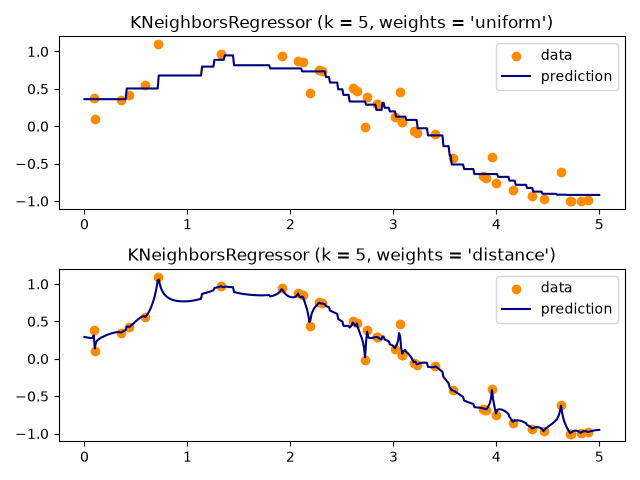

In [ ]:
file_path_pic_KNN_for_regression = '/content/drive/MyDrive/Hình project google colab/KNN/sphx_glr_plot_regression_001.png'
display(Image(filename=file_path_pic_KNN_for_regression, width=600))

# Ưu điểm của KNN
- Độ phức tạp tính toán của quá trình huấn luyện gần như bằng 0. Việc tính
bình phương l2-norm của mỗi điểm dữ liệu huấn luyện có thể được thực hiện
trước trong bước này.
- Việc dự đoán kết quả của dữ liệu mới tương đối đơn giản sau khi đã xác định
được các điểm lân cận.
- KNN không không cần giả sử về phân phối của từng nhãn.
# Nhược điểm của KNN
- KNN nhạy cảm với nhiễu khi K nhỏ.
- Khi sử dụng KNN, phần lớn tính toán nằm ở pha kiểm tra. Trong đó việc
tính khoảng cách tới từng điểm dữ liệu huấn luyện tốn nhiều thời gian, đặc
biệt là với các cơ sở dữ liệu có số chiều lớn và có nhiều điểm dữ liệu (có thể xem lại ví dụ về MNIST phía trên). K càng
lớn thì độ phức tạp càng cao. Ngoài ra, việc lưu toàn bộ dữ liệu trong bộ nhớ
cũng ảnh hưởng tới hiệu năng của KNN.

Ngoài ra thì thay vì sử dụng Brute force để tính từng cặp giá trị thì ta có thể dùng thêm các thuật toán khác để tăng tốc khả năng tìm kiếm này

Trong thư viện Scikit-learn có sử dụng thêm [BallTree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.BallTree.html) và [KDTree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html)

# KNN Python Implementation without using Scikit-learn
#

In [175]:
# The first approach: compute distance using vector
from collections import Counter

def euclidean_distance_fast(z, X):
  X2 = np.sum(X * X, axis=1)
  z2 = np.sum(z * z)
  return X2 + z2 - 2 * X.dot(z)

class KNN:
  def __init__(self, k):
      self.k = k

  def fit(self, X_train, y_train):
      self.X_train = np.array(X_train, dtype=float)
      self.y_train = np.array(y_train)

  def predict(self, X_test):
      X_test = np.array(X_test, dtype=float)
      predicted_labels = [self._predict(x) for x in X_test]
      return np.array(predicted_labels)

  def _predict(self, x):
    # Compute distance
    distances = euclidean_distance_fast(x, self.X_train)

    # Sort the result, get the first k elements in the array
    k_indices = np.argsort(distances)[:self.k]
    k_nearest_label = [self.y_train[i] for i in k_indices]
    most_common_element = Counter(k_nearest_label).most_common(1)
    return most_common_element[0][0]

Chạy thử với Iris data sử dụng cách code thứ nhất

In [180]:
model_KNN_Scratch = KNN(k=7)
model_KNN_Scratch.fit(X_train, y_train)
start_time_first_approach = time()
y_pred_KNN_Scratch = model_KNN_Scratch.predict(X_test)
end_time_first_approach = time()
print(f'Accuracy of 7NN using L2-norm distance: {accuracy_score(y_test, y_pred_KNN_Scratch) * 100:.4f}%')
print(f'Running time of first approach: {end_time_first_approach - start_time_first_approach}s')

Accuracy of 7NN using L2-norm distance: 93.8462%
Running time of first approach: 0.012764215469360352s


In [181]:
# The second approach: using a whole X_test when computes distances

def euclidean_distance_fast_version2(Z, X):
  X2 = np.sum(X*X, 1)
  Z2 = np.sum(Z*Z, 1)
  return Z2.reshape(-1, 1) + X2.reshape(1, -1) - 2*Z.dot(X.T)

class KNN_version_2:
  def __init__(self, k):
    self.k = k

  def fit(self, X_train, y_train):
    self.X_train = X_train
    self.y_train = y_train

  def predict(self, X_test):
    distances = euclidean_distance_fast_version2(X_test, self.X_train)
    # Sort the result, get the first k elements in the array
    predicted_labels = []
    for dist_row in distances:
        k_indices = np.argsort(dist_row)[:self.k]

        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        predicted_labels.append(most_common[0][0])

    return np.array(predicted_labels)

Cách thứ 2

In [182]:
model_KNN_Scratch_second_approach = KNN_version_2(k=7)
model_KNN_Scratch_second_approach.fit(X_train, y_train)
start_time_second_approach = time()
y_pred_KNN_Scratch_second_approach = model_KNN_Scratch_second_approach.predict(X_test)
end_time_second_approach = time()
print(f'Accuracy of 7NN using L2-norm distance: {accuracy_score(y_test, y_pred_KNN_Scratch_second_approach) * 100:.4f}%')
print(f'Running time of second approach: {end_time_second_approach - start_time_second_approach}s')

Accuracy of 7NN using L2-norm distance: 93.8462%
Running time of second approach: 0.005823612213134766s


# Reference
[1]: Machine Learning cơ bản - Vũ Hữu Tiệp (dạng sách).  
[2]: [Patrick Loeber - KNN in Python](https://www.youtube.com/watch?v=ngLyX54e1LU&list=PLqnslRFeH2Upcrywf-u2etjdxxkL8nl7E)  
[3]: [Nearest Neighbor Pattern Classification](https://isl.stanford.edu/~cover/papers/transIT/0021cove.pdf)  
[4]: [The Elements of Statistical Learning (ESL), Section 2 - Trevor Hastie, Robert Tibshirani, Jerome Friedman](https://jqichina.wordpress.com/wp-content/uploads/2012/02/the-elements-of-statistical-learning.pdf)
[5]: Understanding Machine Learning:
From Theory to Algorithms - Shai Shalev-Shwartz and Shai Ben-David